## **【程式4.1】**

In [1]:
# 從keras.datasets套件中匯入imdb資料集
from tensorflow.keras.datasets import imdb

# 匯入後進行資料讀取
# num_words = 10000，表示讀取資料時只會保留前10000個最常出現的單字
(train_data, train_labels),(test_data, test_labels) = imdb.load_data(num_words = 10000)

In [2]:
# 由Output結果可得知，一筆評論就是使用一組數字串列來表示(數字編號是根據字典來編號的)
train_data[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [3]:
# 由Output結果可得知，該筆評論是正向評論。
train_labels[0]

np.int64(1)

In [4]:
# 使用下方程式找出train_data內的最大資料量
# 確認當前在第一個程式區塊中，設定的num_words = 10000是否有效
# Output應等於9999才對
max([max(sequence) for sequence in train_data])

9999

## **【程式4.2】**

In [5]:
# 取得單字(鍵)對應數字(值)的字典
word_index = imdb.get_word_index()

# 使用dict()，將"單字對應數字的字典"反轉為"數字對應單字的字典"
reverse_word_index = dict(
    [(value,key) for (key,value) in word_index.items()])

# 將第一筆評論的所有數字轉換成英文單字
decoded_review = ' '.join(
    [reverse_word_index.get(i - 3,'?') for i in train_data[0]])

In [6]:
# 若單字的使用頻率高，編號就越前面
word_index['a']

3

In [7]:
# 單字"the"的使用頻率最高
word_index['the']

1

In [8]:
# 單字"perfect"的使用頻率較低，因此字典內的數字編號較後面
word_index['perfect']

401

In [9]:
' '.join([reverse_word_index.get(i - 3,'?') for i in train_data[0]])

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

## **【程式4.3】**

In [22]:
# 匯入 NumPy 函式庫，並將其別名設定為 np，NumPy 用於高效地處理陣列和數值運算。
import numpy as np

# 定義一個名為 vectorize_sequences 的函式，用於將序列資料向量化。
# 函式接受兩個參數：sequences (資料序列，如電影評論的數字列表) 和 dimension (向量的維度，預設為 10000)。
def vectorize_sequences(sequences, dimension = 10000):

  # 創建一個全為零的 NumPy 陣列，形狀為 (序列數量, 維度)。
  # 這個陣列將用於儲存向量化後的資料，每一列代表一個評論，每個元素代表一個單字是否出現。
  results = np.zeros((len(sequences), dimension))

  # 迭代處理每一個輸入序列及其索引。
  # i 是序列在 `sequences` 中的索引，sequence 是該評論的數字列表。
  for i, sequence in enumerate(sequences):

    # 將 `results` 陣列中對應序列位置和單字索引的位置設定為 1。
    # 這表示在當前評論 (第 i 列) 中，索引為 `sequence` 中的單字是存在的。
    # 這種轉換稱為「詞袋模型 (Bag-of-Words)」或「one-hot 編碼」。
    results[i, sequence] = 1

  # 函式返回向量化後的結果陣列。
  return results

# 呼叫 vectorize_sequences 函式，將訓練資料 train_data 轉換為向量化表示。
# x_train 將是一個二維 NumPy 陣列，每一行是一個訓練評論的向量表示。
x_train = vectorize_sequences(train_data)
# 呼叫 vectorize_sequences 函式，將測試資料 test_data 轉換為向量化表示。
# x_test 將是一個二維 NumPy 陣列，每一行是一個測試評論的向量表示。
x_test = vectorize_sequences(test_data)

# 將訓練標籤 tran_labels 轉換為 NumPy 陣列，並將其資料類型設定為 32 位浮點數。
# 這是深度學習模型通常需要的輸入格式
y_train = np.asarray(train_labels).astype('float32')
# 將測試標籤 test_labels 轉換為 NumPy 陣列，並將其資料類型設定為 32 位浮點數。
# 這是深度學習模型通常需要的輸入格式。
y_test = np.asarray(test_labels).astype('float32')

In [24]:
x_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

## **【程式4.4】**

In [25]:
# 從 TensorFlow 函式庫中匯入 keras 模組，keras 是一個高階 API，用於建立和訓練深度學習模型。
from tensorflow import keras
# 從 keras 模組中匯入 layers 模組，用於建立神經網路中的層 (layers)。
from tensorflow.keras import layers

# 初始化一個 Sequential 模型，這是 Keras 中最簡單的一種模型，它允許您逐層堆疊模型。
model = keras.Sequential([
  # 加入第一個 Dense 層 (全連接層)。它有 16 個神經元，並使用 'relu' (Rectified Linear Unit) 作為激活函數。
  # Relu 激活函數有助於引入非線性，讓模型能夠學習更複雜的模式。
  layers.Dense(16, activation = 'relu'),
  # 加入第二個 Dense 層。同樣有 16 個神經元，並使用 'relu' 作為激活函數。
  layers.Dense(16, activation = 'relu'),
  # 加入輸出層。它只有 1 個神經元，並使用 'sigmoid' 作為激活函數。因為這是一個二元分類問題 (例如：判斷評論是正面還是負面)，
  # Sigmoid 激活函數會將輸出壓縮到 0 到 1 之間，可以解釋為類別的機率。
  layers.Dense(1, activation = 'sigmoid')
])

## **【程式4.5】**

In [27]:
model.compile(optimizer = 'rmsprop',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

## **【程式4.6】**

In [13]:
x_val = x_train[:10000]

partial_x_train = x_train[10000:]

y_val = y_train[:10000]

partial_y_train = y_train[10000:]

## **【程式4.7】**

In [15]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs = 20,
                    batch_size = 512,
                    validation_data = (x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.6727 - loss: 0.6197 - val_accuracy: 0.8633 - val_loss: 0.4088
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8982 - loss: 0.3452 - val_accuracy: 0.8843 - val_loss: 0.3164
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9282 - loss: 0.2389 - val_accuracy: 0.8838 - val_loss: 0.2933
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9443 - loss: 0.1882 - val_accuracy: 0.8743 - val_loss: 0.3111
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9473 - loss: 0.1639 - val_accuracy: 0.8832 - val_loss: 0.2931
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9654 - loss: 0.1276 - val_accuracy: 0.8724 - val_loss: 0.3357
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9651 - loss: 0.1160 - val_accuracy: 0.8788 - val_loss: 0.3138
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9734 - loss: 0.0953 - val_accuracy: 0.8850 - v

In [16]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## **【程式4.8】**

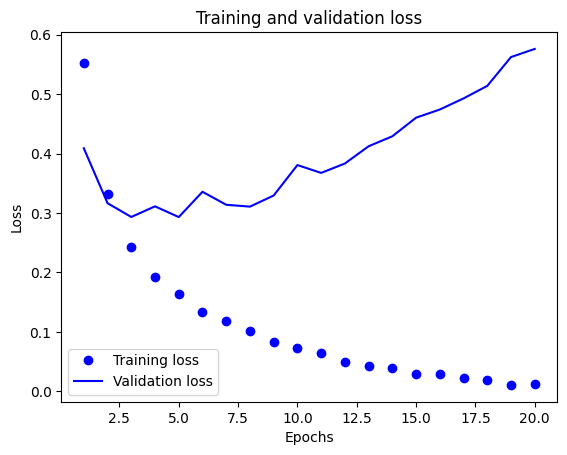

In [17]:
# 匯入 Matplotlib 函式庫中的 pyplot 模組，通常縮寫為 plt，用於繪製圖表和視覺化數據。
import matplotlib.pyplot as plt

# 從訓練歷史記錄物件 history 中取出 history 屬性，這個屬性包含訓練過程中的各種指標數據 (例如損失和準確度)。
history_dict = history.history
# 從 history_dict 中提取訓練過程中的損失值 (loss)，這些值代表模型在訓練資料上的表現。
loss_values = history_dict['loss']
# 從 history_dict 中提取驗證過程中的損失值 (validation loss)，這些值代表模型在驗證資料上的表現。
val_loss_values = history_dict['val_loss']

# 創建一個 epoch 範圍，從 1 到損失值的數量。這將作為圖表的 X 軸，表示訓練的週期數。
epochs = range(1, len(loss_values) + 1)
# 繪製訓練損失的散點圖 (b: 藍色, o: 圓點標記)，並標示 'Training loss'。
plt.plot(epochs, loss_values, 'bo', label = 'Training loss')
# 繪製驗證損失的線圖 (b: 藍色, 實線)，並標示 'Validation loss'。
plt.plot(epochs, val_loss_values, 'b', label = 'Validation loss')
# 設定圖表的標題為 'Training and validation loss'。
plt.title('Training and validation loss')
# 設定 X 軸的標籤為 'Epochs'。
plt.xlabel('Epochs')
# 設定 Y 軸的標籤為 'Loss'。
plt.ylabel('Loss')
# 顯示圖表的圖例，以便區分不同的線條 (訓練損失和驗證損失)。
plt.legend()

# 顯示繪製好的圖表。
plt.show()

## **【程式4.9】**

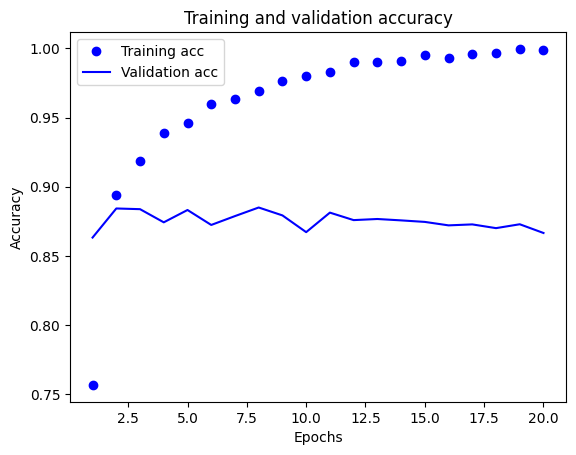

In [18]:
# 清除當前圖形，為新的圖形繪製做準備。
plt.clf()
# 從 history_dict 中提取訓練過程中的準確度 (accuracy)，這些值代表模型在訓練資料上的表現。
acc = history_dict['accuracy']
# 從 history_dict 中提取驗證過程中的準確度 (validation accuracy)，這些值代表模型在驗證資料上的表現。
val_acc = history_dict['val_accuracy']

# 繪製訓練準確度的散點圖 (bo: 藍色圓點標記)，並標示 'Training acc'。
plt.plot(epochs, acc, 'bo', label = 'Training acc')
# 繪製驗證準確度的線圖 (b: 藍色實線)，並標示 'Validation acc'。
plt.plot(epochs, val_acc, 'b', label = 'Validation acc')
# 設定圖表的標題為 'Training and validation accuracy'。
plt.title('Training and validation accuracy')
# 設定 X 軸的標籤為 'Epochs'。
plt.xlabel('Epochs')
# 設定 Y 軸的標籤為 'Accuracy'。
plt.ylabel('Accuracy')
# 顯示圖表的圖例，以便區分不同的線條 (訓練準確度和驗證準確度)。
plt.legend()

# 顯示繪製好的圖表。
plt.show()

## **【程式4.10】**

In [19]:
# 初始化一個 Sequential 模型，這是 Keras 中最簡單的一種模型，它允許您逐層堆疊模型。
# 注意：這裡使用變數名稱 'modle' (拼寫錯誤，通常會使用 'model')。
modle = keras.Sequential([
  # 加入第一個 Dense 層 (全連接層)。它有 16 個神經元，並使用 'relu' (Rectified Linear Unit) 作為激活函數。
  layers.Dense(16, activation = 'relu'),
  # 加入第二個 Dense 層。同樣有 16 個神經元，並使用 'relu' 作為激活函數。
  layers.Dense(16, activation = 'relu'),
  # 加入輸出層。它只有 1 個神經元，並使用 'sigmoid' 作為激活函數。這用於二元分類問題，輸出介於 0 到 1 之間的機率值。
  layers.Dense(1, activation = 'sigmoid')
])

# 配置模型的訓練過程。指定優化器、損失函數和評估指標。
modle.compile(optimizer = 'rmsprop',
              loss = 'binary_crossentropy', # 對於二元分類問題，常用二元交叉熵作為損失函數。
              metrics = ['accuracy']) # 準確度是常用的評估指標。

# 訓練模型。使用全部的訓練資料 (x_train, y_train)，訓練 4 個週期 (epochs = 4)，並設定批次大小為 512。
modle.fit(x_train, y_train, epochs = 4, batch_size = 512)
# 使用測試資料 (x_test, y_test) 評估模型的性能。注意這裡將 'model' 更正為 'modle' 以評估剛訓練的模型。
results = modle.evaluate(x_test, y_test)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7355 - loss: 0.5496
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9085 - loss: 0.2765
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9288 - loss: 0.2064
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9396 - loss: 0.1763
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8855 - loss: 0.2855


In [20]:
results

[0.285556435585022, 0.8862400054931641]

## **實際環境使用**

使用predict方法，對評論文章進行預測(是正評還是負評)

In [21]:
# 對x_test測試集的評論文章做預測
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.00929786],
       [1.        ],
       [0.72137403],
       ...,
       [0.00232504],
       [0.00465845],
       [0.8051255 ]], dtype=float32)